### Random forest training, tuning and results

In [2]:
# Import all the libraries for the random forest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, classification_report, confusion_matrix, recall_score, roc_auc_score, precision_score, accuracy_score
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold


In [3]:
# File loading
import sys
from pathlib import Path
_root = Path.cwd().resolve()
for _ in range(16):
    if (_root / "pyproject.toml").exists():
        break
    _root = _root.parent
else:
    raise FileNotFoundError("Run this notebook from inside the project repository.")
sys.path.insert(0, str(_root / "src"))
from conflict_project.repo_paths import training_parquet_path
parquet_path = training_parquet_path()

df = pd.read_parquet(parquet_path)
# Drop nas
df = df.dropna()
df['target'] = (df['conflict_count'] >= 1).astype(int)

# Select the features created
features = df.drop(['GEOID', 'conflict_count', 'target'], axis=1)
features = pd.get_dummies(features, columns=['year'], prefix='year')
X = features
y = df['target']

To adress class imbalance: SMOTE

In [4]:
# Pre-processing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply SMOTE for class imbalance
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# Define the cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define parameter grid to search
param_grid = {
    # Different number of trees to run through CV
    'n_estimators': [100, 200, 300, 500],
    # Maximum depth of trees
    'max_depth': [None, 10, 20],
    # Minimum samples required to split
    'min_samples_split': [2, 5, 10],
    # Minimum samples required at leaf node
    'min_samples_leaf': [1, 2, 4],
    # Adjust weights inversely proportional to class frequencies
    'class_weight': ['balanced', None]
}

# Initialize the Random Forest classifier
rf = RandomForestClassifier(random_state=42)

# Set up GridSearchCV with recall as the scoring metric
grid_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    # Optimize for recall
    scoring='recall_weighted',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit the model
print("Training Random Forest with GridSearchCV...")
grid_search.fit(X_train_smote, y_train_smote)



Training Random Forest with GridSearchCV...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(random_state=42), n_iter=50,
                   n_jobs=-1,
                   param_distributions={'class_weight': ['balanced', None],
                                        'max_depth': [None, 10, 20],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='recall_weighted', verbose=1)

Best parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'class_weight': None}

--- Random Forest Model (Optimized) ---
Accuracy: 0.9291
Recall: 0.6975
F1 Score: 0.6150
Precision: 0.5500

Confusion Matrix:
[[5936  315]
 [ 167  385]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      6251
           1       0.55      0.70      0.62       552

    accuracy                           0.93      6803
   macro avg       0.76      0.82      0.79      6803
weighted avg       0.94      0.93      0.93      6803



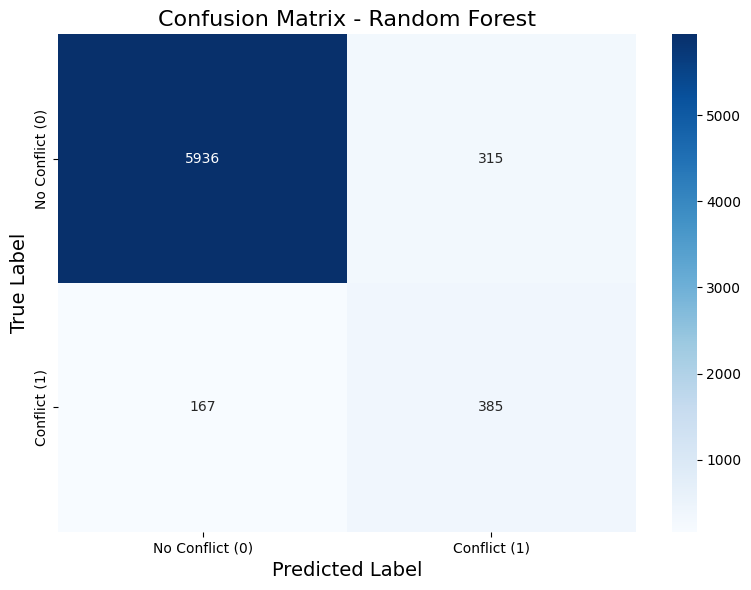

In [5]:
# Get best model
best_rf = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")

# Predict on test set
y_pred_rf = best_rf.predict(X_test_scaled)

# Evaluate
print("\n--- Random Forest Model (Optimized) ---")
print(f"Accuracy: {best_rf.score(X_test_scaled, y_test):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf, pos_label=1):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf, pos_label=1):.4f}")

print(f"Precision: {precision_score(y_test, y_pred_rf, pos_label=1):.4f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_rf)
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Conflict (0)', 'Conflict (1)'],
            yticklabels=['No Conflict (0)', 'Conflict (1)'])
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix - Random Forest', fontsize=16)
plt.tight_layout()
plt.show()

# Feature importance
feature_importance = best_rf.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})
importance_df = importance_df.sort_values('Importance', ascending=False).head(10)



In [6]:
# Calculate all metrics
accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, pos_label=1)
recall = recall_score(y_test, y_pred_rf, pos_label=1)
f1 = f1_score(y_test, y_pred_rf, pos_label=1)

# Get classification report as dictionary for better formatting
report_dict = classification_report(y_test, y_pred_rf, output_dict=True)

# Create a comprehensive results DataFrame
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)'],
    'Value': [accuracy, precision, recall, f1]
})

print("=== Random Forest Performance Metrics ===")
print(results_df.to_string(index=False))

# Detailed per-class metrics
print("\n=== Per-Class Metrics ===")
per_class_df = pd.DataFrame(report_dict).transpose().round(4)
print(per_class_df)

# Export to LaTeX
print("\n=== LaTeX Table - Overall Metrics ===")
print(results_df.round(4).to_latex(index=False, escape=False))

print("\n=== LaTeX Table - Per-Class Metrics ===")
print(per_class_df.to_latex(escape=False))

# Create a more publication-ready table
publication_metrics = pd.DataFrame({
    'Class': ['No Conflict (0)', 'Conflict (1)', 'Macro Avg', 'Weighted Avg'],
    'Precision': [
        report_dict['0']['precision'],
        report_dict['1']['precision'], 
        report_dict['macro avg']['precision'],
        report_dict['weighted avg']['precision']
    ],
    'Recall': [
        report_dict['0']['recall'],
        report_dict['1']['recall'],
        report_dict['macro avg']['recall'], 
        report_dict['weighted avg']['recall']
    ],
    'F1-Score': [
        report_dict['0']['f1-score'],
        report_dict['1']['f1-score'],
        report_dict['macro avg']['f1-score'],
        report_dict['weighted avg']['f1-score']
    ],
    'Support': [
        int(report_dict['0']['support']),
        int(report_dict['1']['support']),
        int(report_dict['macro avg']['support']),
        int(report_dict['weighted avg']['support'])
    ]
})

print("\n=== Publication-Ready LaTeX Table ===")
latex_table = publication_metrics.round(4).to_latex(
    index=False, 
    escape=False,
    column_format='lcccc',
    caption='Random Forest Classification Results',
    label='tab:rf_results'
)
print(latex_table)

# Confusion Matrix as LaTeX
print("\n=== Confusion Matrix for LaTeX ===")
cm_df = pd.DataFrame(cm, 
                     index=['Actual No Conflict', 'Actual Conflict'],
                     columns=['Predicted No Conflict', 'Predicted Conflict'])
print(cm_df.to_latex())

# Summary statistics for the paper
print(f"\n=== Summary for Paper ===")
print(f"The Random Forest model achieved:")
print(f"- Overall Accuracy: {accuracy:.1%}")
print(f"- Conflict Detection Recall: {recall:.1%}")
print(f"- Conflict Prediction Precision: {precision:.1%}")
print(f"- F1-Score: {f1:.3f}")
print(f"- True Negatives: {cm[0,0]:,}")
print(f"- False Positives: {cm[0,1]:,}")
print(f"- False Negatives: {cm[1,0]:,}")
print(f"- True Positives: {cm[1,1]:,}")

=== Random Forest Performance Metrics ===
             Metric    Value
           Accuracy 0.929149
Precision (Class 1) 0.550000
   Recall (Class 1) 0.697464
 F1-Score (Class 1) 0.615016

=== Per-Class Metrics ===
              precision  recall  f1-score    support
0                0.9726  0.9496    0.9610  6251.0000
1                0.5500  0.6975    0.6150   552.0000
accuracy         0.9291  0.9291    0.9291     0.9291
macro avg        0.7613  0.8235    0.7880  6803.0000
weighted avg     0.9383  0.9291    0.9329  6803.0000

=== LaTeX Table - Overall Metrics ===
\begin{tabular}{lr}
\toprule
Metric & Value \\
\midrule
Accuracy & 0.929100 \\
Precision (Class 1) & 0.550000 \\
Recall (Class 1) & 0.697500 \\
F1-Score (Class 1) & 0.615000 \\
\bottomrule
\end{tabular}


=== LaTeX Table - Per-Class Metrics ===
\begin{tabular}{lrrrr}
\toprule
 & precision & recall & f1-score & support \\
\midrule
0 & 0.972600 & 0.949600 & 0.961000 & 6251.000000 \\
1 & 0.550000 & 0.697500 & 0.615000 & 552.0000

/var/folders/m8/p0y07mnx0xj8nxd8l9zj7fn00000gn/T/ipykernel_26665/1657164477.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


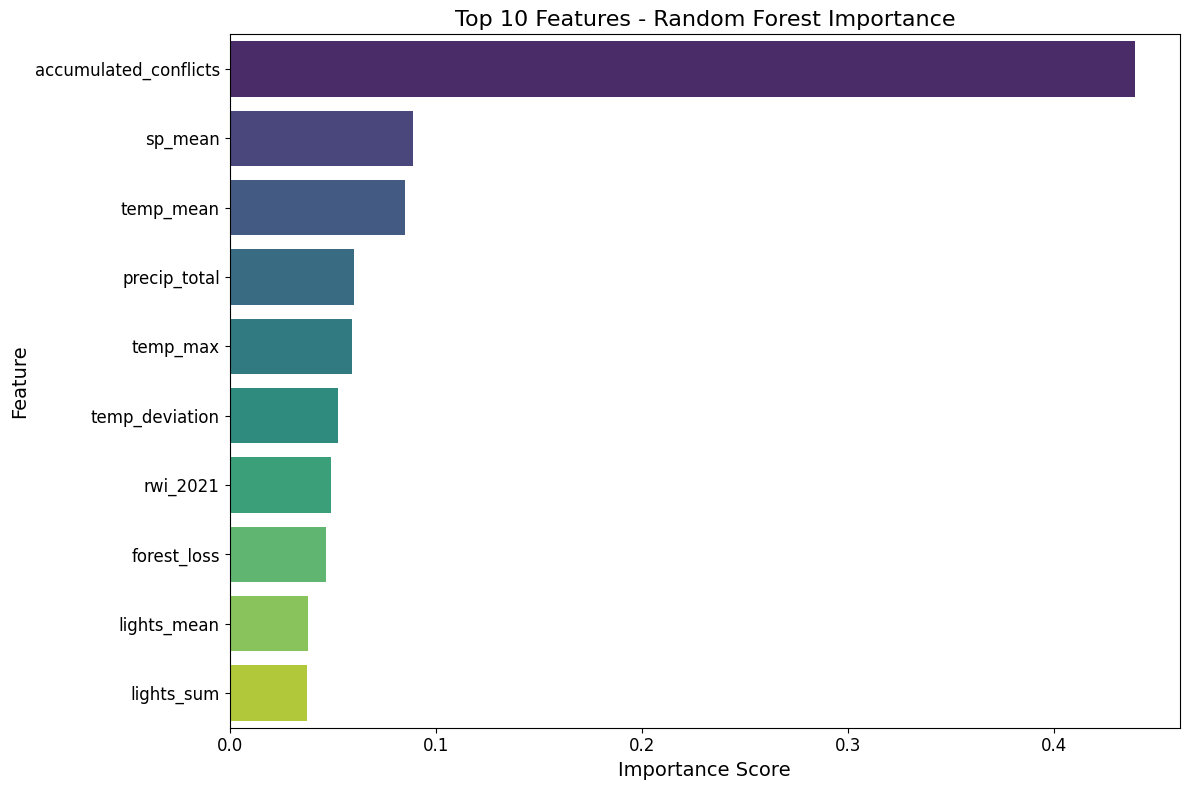

In [7]:
# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Features - Random Forest Importance', fontsize=16)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.tight_layout()
plt.show()